# 04 - Master Integration & EDA
Objective: merge scaled datasets and visualise trade flows, sector demand, heatmaps, correlations.
Input: data/processed/03_*.csv | Output: data/processed/04_master_*.csv + figures in reports/figures/

In [1]:
import numpy as np
import pandas as pd
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize']=(12,6)
PROJECT_ROOT=Path.cwd().parent.parent
PROCESSED_DIR=PROJECT_ROOT/'data'/'processed'
PLOTS_DIR=PROJECT_ROOT/'reports'/'figures'
PLOTS_DIR.mkdir(parents=True,exist_ok=True)
files={'comtrade':'03_comtrade_scaled.csv','worldbank':'03_worldbank_scaled.csv','wto_demand':'03_wto_demand_scaled.csv','trade_balance':'03_trade_balance_scaled.csv','diversification':'03_diversification_scaled.csv'}
dfs={}
for name,fname in files.items():
    p=PROCESSED_DIR/fname
    dfs[name]=pd.read_csv(p) if p.exists() else pd.DataFrame()
    print(f'{name:20s}: {dfs[name].shape}')

comtrade            : (6, 37)
worldbank           : (5375, 43)
wto_demand          : (181, 18)
trade_balance       : (1, 16)
diversification     : (11, 13)


## 4.2 - Master Country-Year Panel

In [2]:
if not dfs['worldbank'].empty:
    m=dfs['worldbank'].copy()
    m['year']=pd.to_numeric(m['year'],errors='coerce')
    m['is_algeria']=m['country'].str.lower().str.contains('algeria',na=False)
    if not dfs['diversification'].empty:
        d=dfs['diversification'].copy();d['year']=pd.to_numeric(d['year'],errors='coerce')
        m=m.merge(d,on='year',how='left',suffixes=('','_div'))
    if not dfs['trade_balance'].empty:
        b=dfs['trade_balance'].copy();b['refyear']=pd.to_numeric(b['refyear'],errors='coerce');b.rename(columns={'refyear':'year'},inplace=True)
        m=m.merge(b,on='year',how='left',suffixes=('','_bal'))
    m.to_csv(PROCESSED_DIR/'04_master_country_year.csv',index=False)
    print('Saved 04_master_country_year.csv',m.shape)
    display(m.head())
else:
    m=pd.DataFrame();print('World Bank missing')

Saved 04_master_country_year.csv (5375, 71)


,country,country_code,year,NE.IMP.GNFS.ZS,NY.GDP.MKTP.CD,NY.GDP.MKTP.KD.ZG,NY.GDP.PCAP.CD,SP.POP.TOTL,TG.VAL.TOTL.GD.ZS,gdp_growth_lag1,...,trade_balance_pct_of_exports,exports_std,imports_std,trade_balance_std,exports_minmax,imports_minmax,trade_balance_minmax,exports_robust,imports_robust,trade_balance_robust
0,Aruba,ABW,2000.0,70.686869,1.873453e+09,7.622921,20681.023027,90588.0,272.544938,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aruba,ABW,2001.0,69.394325,1.896457e+09,4.182002,20740.132583,91439.0,252.839903,7.622921,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Aruba,ABW,2002.0,68.666458,1.961844e+09,-0.944953,21307.248251,92074.0,178.658484,4.182002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Aruba,ABW,2003.0,70.063078,2.044112e+09,1.110505,21949.485996,93128.0,217.649551,-0.944953,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Aruba,ABW,2004.0,67.765371,2.254831e+09,7.293728,23700.631990,95138.0,311.508971,1.110505,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4.3 - Master Sector-Year Panel

In [3]:
if not dfs['wto_demand'].empty:
    s=dfs['wto_demand'].copy();s['year']=pd.to_numeric(s['year'],errors='coerce')
    if not dfs['diversification'].empty:
        d=dfs['diversification'].copy();d['year']=pd.to_numeric(d['year'],errors='coerce')
        s=s.merge(d,on='year',how='left',suffixes=('','_div'))
    s.to_csv(PROCESSED_DIR/'04_master_sector_year.csv',index=False)
    print('Saved 04_master_sector_year.csv',s.shape)
    display(s.head())
else:
    s=pd.DataFrame();print('WTO demand missing')

Saved 04_master_sector_year.csv (181, 30)


,year,product_sector,value,global_demand_index,demand_growth_rate_pct,demand_3yr_ma,value_std,global_demand_index_std,demand_growth_rate_pct_std,demand_3yr_ma_std,...,shannon_entropy_norm,hhi_std,shannon_entropy_std,shannon_entropy_norm_std,hhi_minmax,shannon_entropy_minmax,shannon_entropy_norm_minmax,hhi_robust,shannon_entropy_robust,shannon_entropy_norm_robust
0,2015,Agricultural Products,11007.890104,0.063725,NaN,11007.890104,-0.214487,-0.223341,-0.044179,-0.213925,...,0.626887,-0.375454,0.434358,0.434358,0.000000,1.000000,1.000000,-1.638048,1.124702,1.124702
1,2016,Agricultural Products,9971.365942,0.064653,-9.416193,10489.628023,-0.239687,-0.219434,-0.453352,-0.226791,...,0.625067,-0.363905,0.423957,0.423957,0.003266,0.997097,0.997097,-1.389345,1.040218,1.040218
2,2017,Agricultural Products,10176.748441,0.062626,2.059723,10385.334829,-0.234694,-0.227972,-0.023260,-0.229380,...,0.620254,-0.359013,0.396442,0.396442,0.004650,0.989419,0.989419,-1.283994,0.816728,0.816728
3,2018,Agricultural Products,8674.170198,0.049214,-14.764817,9607.428194,-0.271225,-0.284482,-0.653807,-0.248692,...,0.599838,-0.297809,0.279735,0.279735,0.021961,0.956852,0.956852,0.034051,-0.131209,-0.131209
4,2019,Agricultural Products,9145.108000,0.057193,5.429197,9332.008880,-0.259775,-0.250865,0.103021,-0.255529,...,0.610587,-0.316185,0.341180,0.341180,0.016763,0.973998,0.973998,-0.361678,0.367875,0.367875


## 4.4 - Visualisations

In [4]:
def save_or_show(fig,fname):
    path=PLOTS_DIR/fname
    fig.savefig(path,bbox_inches='tight',dpi=150)
    print('Saved',path)
    plt.show()

### Algeria Trade Flow Time Series

Saved C:\Users\DELL\ML-project\algerian-export-ml\reports\figures\01_algeria_trade_flows.png


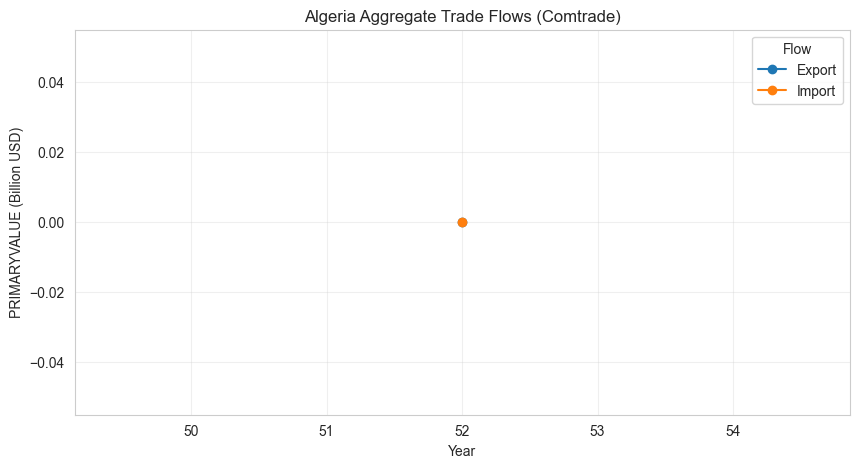

In [5]:
if not dfs['comtrade'].empty and 'refyear' in dfs['comtrade'].columns:
    c=dfs['comtrade'].copy();c['refyear']=pd.to_numeric(c['refyear'],errors='coerce')
    val_col=None
    for col in ['primaryvalue','fobvalue','cifvalue']:
        if col in c.columns and c[col].notna().any():val_col=col;break
    if val_col:
        p=c.groupby(['refyear','flow_type'])[val_col].sum().unstack().reset_index().sort_values('refyear')
        fig,ax=plt.subplots(figsize=(10,5))
        for col in p.columns:
            if col!='refyear':ax.plot(p['refyear'],p[col]/1e9,marker='o',label=str(col).title())
        ax.set_title('Algeria Aggregate Trade Flows (Comtrade)');ax.set_xlabel('Year');ax.set_ylabel(f'{val_col.upper()} (Billion USD)');ax.legend(title='Flow');ax.grid(True,alpha=0.3)
        save_or_show(fig,'01_algeria_trade_flows.png')
    else:print('No value col')
else:print('Comtrade unavailable')

### Sector Demand Trends (WTO)

Saved C:\Users\DELL\ML-project\algerian-export-ml\reports\figures\02_sector_demand_trends.png


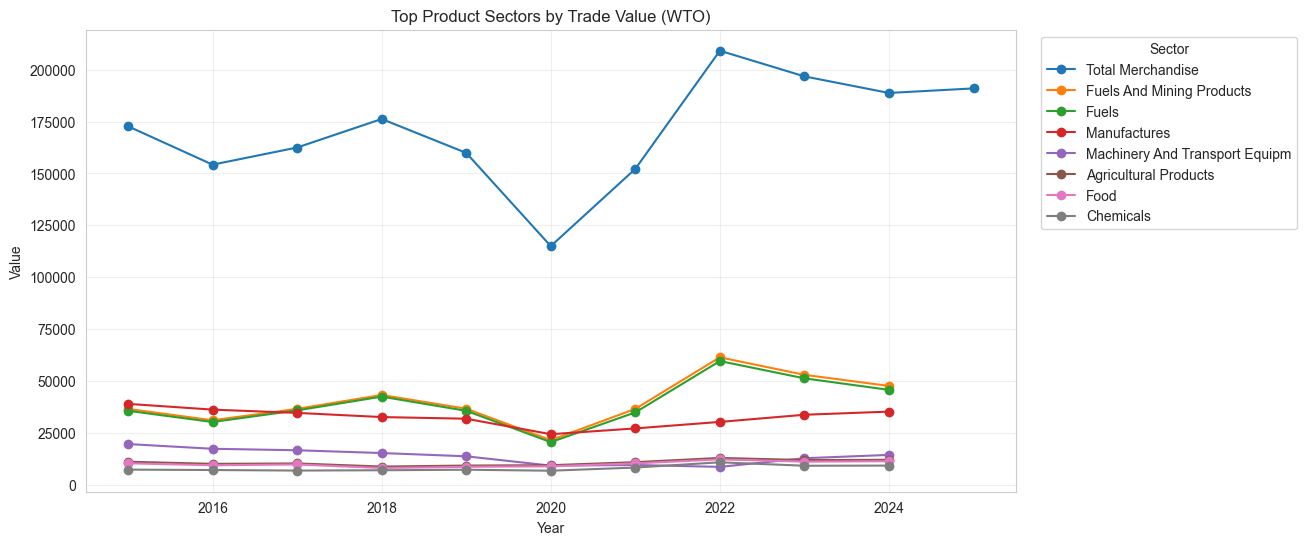

In [6]:
if not s.empty and 'product_sector' in s.columns:
    top=s.groupby('product_sector')['value'].mean().sort_values(ascending=False).head(8).index.tolist()
    fig,ax=plt.subplots(figsize=(12,6))
    for sec in top:
        sub=s[s['product_sector']==sec].sort_values('year')
        if sub['year'].notna().any():ax.plot(sub['year'],sub['value'],marker='o',label=sec[:30])
    ax.set_title('Top Product Sectors by Trade Value (WTO)');ax.set_xlabel('Year');ax.set_ylabel('Value');ax.legend(title='Sector',bbox_to_anchor=(1.02,1),loc='upper left');ax.grid(True,alpha=0.3)
    save_or_show(fig,'02_sector_demand_trends.png')
else:print('Sector data unavailable')

### GDP Growth Heatmap

Saved C:\Users\DELL\ML-project\algerian-export-ml\reports\figures\03_gdp_growth_heatmap.png


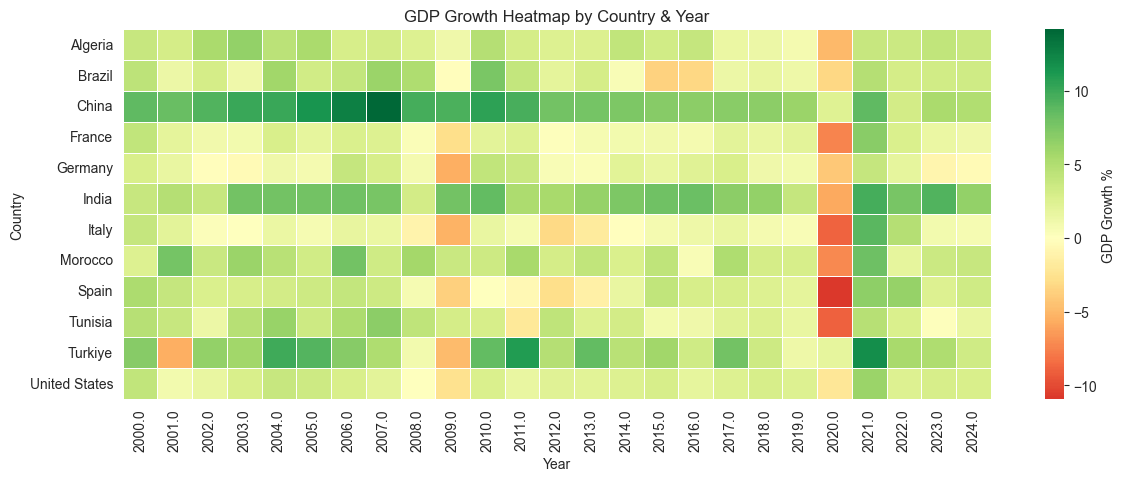

In [7]:
if not m.empty and 'NY.GDP.MKTP.KD.ZG' in m.columns:
    targets=['Algeria','France','China','United States','Germany','Italy','Spain','Morocco','Tunisia','Turkiye','Saudi Arabia','United Arab Emirates','Brazil','India']
    matched=m[m['country'].isin(targets)]['country'].unique().tolist()
    if len(matched)<5:
        ly=m['year'].max();matched=m[m['year']==ly].nlargest(15,'NY.GDP.MKTP.CD' if 'NY.GDP.MKTP.CD' in m.columns else 'NY.GDP.MKTP.KD.ZG')['country'].tolist() if 'NY.GDP.MKTP.CD' in m.columns or 'NY.GDP.MKTP.KD.ZG' in m.columns else []
    if matched:
        h=m[m['country'].isin(matched)][['country','year','NY.GDP.MKTP.KD.ZG']].copy()
        hp=h.pivot(index='country',columns='year',values='NY.GDP.MKTP.KD.ZG')
        hp=hp.dropna(thresh=max(1,int(hp.shape[1]*0.3)),axis=1).dropna(thresh=max(1,int(hp.shape[0]*0.3)),axis=0)
        if not hp.empty:
            fig,ax=plt.subplots(figsize=(14,max(4,len(hp)*0.4)))
            sns.heatmap(hp,cmap='RdYlGn',center=0,annot=False,linewidths=.5,ax=ax,cbar_kws={'label':'GDP Growth %'})
            ax.set_title('GDP Growth Heatmap by Country & Year');ax.set_xlabel('Year');ax.set_ylabel('Country')
            save_or_show(fig,'03_gdp_growth_heatmap.png')
        else:print('Heatmap too sparse')
    else:print('No matched countries')
else:print('GDP growth data unavailable')

### Correlation Matrix

In [8]:
if not m.empty:
    sc=[c for c in m.columns if any(c.endswith(s) for s in ('_std','_minmax','_robust'))]
    raw=['NY.GDP.MKTP.CD','NY.GDP.MKTP.KD.ZG','NY.GDP.PCAP.CD','SP.POP.TOTL','TG.VAL.TOTL.GD.ZS','NE.IMP.GNFS.ZS']
    raw=[c for c in raw if c in m.columns]
    cand=sc if len(sc)>=3 else raw
    if len(cand)>=3:
        corr_df=m[cand].dropna()
        if not corr_df.empty and len(corr_df)>5:
            corr=corr_df.corr()
            fig,ax=plt.subplots(figsize=(10,8))
            sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',center=0,square=True,ax=ax)
            ax.set_title('Correlation Matrix: Macro Features')
            save_or_show(fig,'04_macro_correlation_matrix.png')
        else:print('Not enough observations')
    else:print('Not enough numeric columns')
else:print('Master panel unavailable')

Not enough observations


### Concentration vs Trade Balance Scatter

In [9]:
ready=False
if not m.empty:
    x='hhi' if 'hhi' in m.columns else None
    y=None
    for c in ['trade_balance','trade_balance_pct_of_exports']:
        if c in m.columns:y=c;break
    if x and y:
        sub=m.dropna(subset=[x,y])
        if not sub.empty:
            fig,ax=plt.subplots(figsize=(8,6))
            ax.scatter(sub[x],sub[y],alpha=0.6,edgecolors='k')
            ax.set_xlabel('HHI (Concentration)');ax.set_ylabel(y.replace('_',' ').title());ax.set_title('Product Concentration vs Trade Balance');ax.axhline(0,color='red',linestyle='--',alpha=0.5);ax.grid(True,alpha=0.3)
            save_or_show(fig,'05_concentration_vs_balance.png');ready=True
if not ready:print('Insufficient data for scatter')

Insufficient data for scatter


### Distribution of Scaled Features

Saved C:\Users\DELL\ML-project\algerian-export-ml\reports\figures\06_scaled_feature_distributions.png


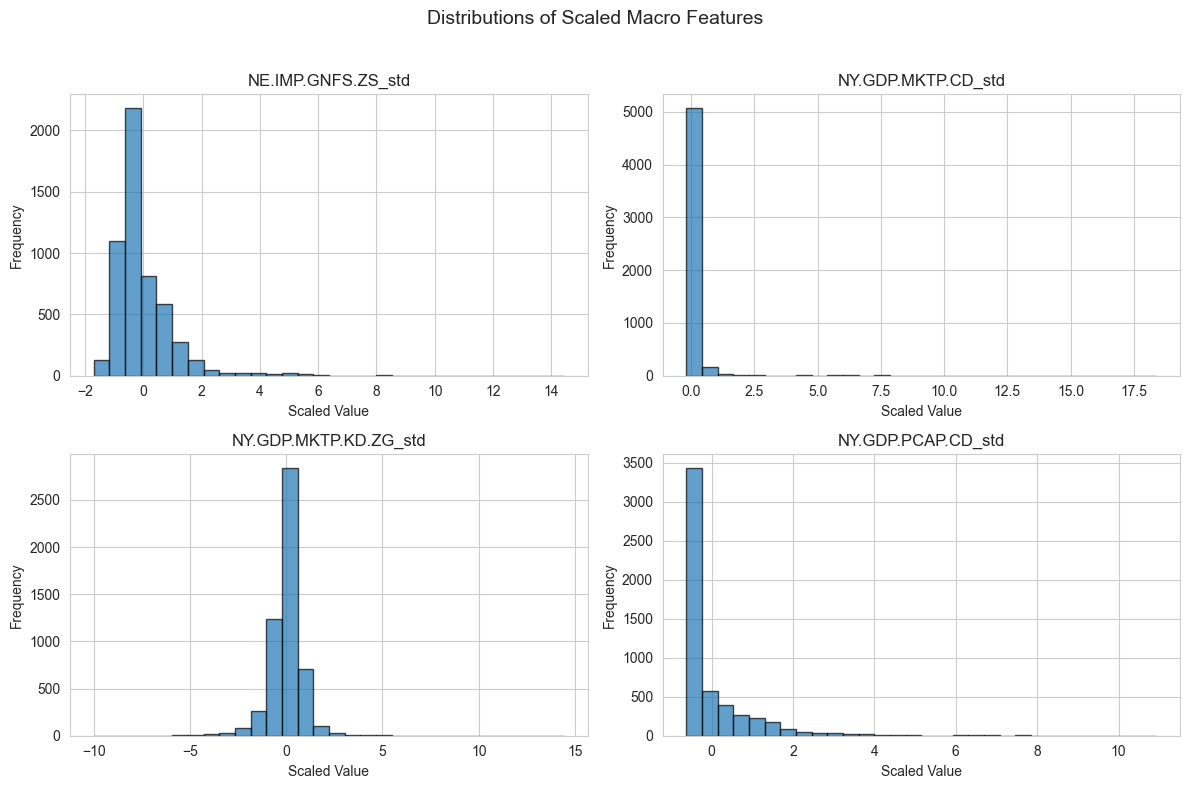

In [10]:
if not m.empty:
    sc=[c for c in m.columns if c.endswith('_std') or c.endswith('_minmax') or c.endswith('_robust')]
    if len(sc)>=4:
        cols=sc[:4];fig,axes=plt.subplots(2,2,figsize=(12,8));axes=axes.ravel()
        for idx,col in enumerate(cols):
            data=m[col].dropna();axes[idx].hist(data,bins=30,edgecolor='k',alpha=0.7);axes[idx].set_title(col);axes[idx].set_xlabel('Scaled Value');axes[idx].set_ylabel('Frequency')
        plt.suptitle('Distributions of Scaled Macro Features',fontsize=14);plt.tight_layout(rect=[0,0,1,0.96])
        save_or_show(fig,'06_scaled_feature_distributions.png')
    else:print('Not enough scaled columns')
else:print('Master panel unavailable')

## 4.5 - Summary & Next Steps
All master datasets saved to `data/processed/`:
- `04_master_country_year.csv`
- `04_master_sector_year.csv`
Figures saved to `reports/figures/`.
Proceed to modelling notebooks (clustering, classification, forecasting).